# Givens QR & Evaluasi SETAR

### QR Givens

Kelompok genap menggunakan Givens Rotations. Rotasi diterapkan pada $A$ dan $b$ untuk memperoleh sistem segitiga $Rx=Q^Tb$ tanpa membentuk $Q$ secara eksplisit.

### Import library

In [46]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=6, suppress=True)

### Load data dan bentuk matriks desain

Fungsi berikut sama dengan yang dipakai pada notebook Persamaan Normal agar kedua metode menyelesaikan $A$ dan $b$ yang sama.

In [47]:
def load_returns(path):
    df = pd.read_csv(path)
    prices = df["Close"].to_numpy(dtype=float)
    returns = (prices[1:] - prices[:-1]) / prices[:-1]
    return df["Date"].to_numpy()[1:], returns


def build_design_matrix(returns, p=2):
    n_rows = len(returns) - p
    A = np.zeros((n_rows, 6))
    b = np.zeros(n_rows)
    regime = np.zeros(n_rows, dtype=int)

    for i, t in enumerate(range(p, len(returns))):
        r_t, r_t1, r_t2 = returns[t], returns[t - 1], returns[t - 2]
        b[i] = r_t
        if r_t1 >= 0:
            A[i, 0], A[i, 1], A[i, 2] = 1.0, r_t1, r_t2
            regime[i] = 1
        else:
            A[i, 3], A[i, 4], A[i, 5] = 1.0, r_t1, r_t2
    return A, b, regime


dates_train, r_train = load_returns("data/stock_train.csv")
A_train, b_train, regime_train = build_design_matrix(r_train)

print("Dimensi A:", A_train.shape)
print("Dimensi b:", b_train.shape)

Dimensi A: (300, 6)
Dimensi b: (300,)


### Implementasi manual Givens QR

Untuk sepasang nilai $a$ dan $b$, koefisien rotasi dihitung dengan

$$r=\sqrt{a^2+b^2},\qquad c=\frac{a}{r},\qquad s=\frac{b}{r}.$$

Blok rotasi $\begin{bmatrix}c&s\\-s&c\end{bmatrix}$ mengubah $[a,b]^T$ menjadi $[r,0]^T$. Rotasi diterapkan berulang kali sampai bagian di bawah diagonal $A$ menjadi nol.

In [48]:
def givens_rotation(a, b):
    r = np.hypot(a, b)
    if r == 0.0:
        return 1.0, 0.0
    return a / r, b / r


def givens_qr(A, b, tol=1e-15):
    R = A.astype(float).copy()
    y = b.astype(float).copy()
    m, n = R.shape
    rotations = 0

    if m < n:
        raise ValueError("Least squares memerlukan jumlah baris A >= jumlah kolom A.")

    for col in range(n):
        for row in range(m - 1, col, -1):
            if abs(R[row, col]) <= tol:
                continue

            c, s = givens_rotation(R[row - 1, col], R[row, col])
            upper = c * R[row - 1, col:] + s * R[row, col:]
            lower = -s * R[row - 1, col:] + c * R[row, col:]
            R[row - 1, col:], R[row, col:] = upper, lower

            y_upper = c * y[row - 1] + s * y[row]
            y_lower = -s * y[row - 1] + c * y[row]
            y[row - 1], y[row] = y_upper, y_lower
            rotations += 1

    return R, y, rotations


def back_substitution(U, rhs, tol=1e-14):
    n = U.shape[0]
    x = np.zeros(n)
    scale = max(1.0, np.max(np.abs(U)))

    for row in range(n - 1, -1, -1):
        if abs(U[row, row]) <= tol * scale:
            raise np.linalg.LinAlgError("Matriks R singular atau mendekati singular.")
        known = U[row, row + 1:] @ x[row + 1:]
        x[row] = (rhs[row] - known) / U[row, row]
    return x

### Penyelesaian least squares

In [49]:
R_full, qt_b, n_rotations = givens_qr(A_train, b_train)
n_param = A_train.shape[1]
R = R_full[:n_param, :]
x_qr = back_substitution(R, qt_b[:n_param])

residual_qr = np.linalg.norm(A_train @ x_qr - b_train)
below_diagonal = np.linalg.norm(np.tril(R, k=-1))

print("Jumlah rotasi       :", n_rotations)
print("x (QR Givens)      :", x_qr)
print(f"Residual norm       : {residual_qr:.8f}")
print(f"Norm bawah diagonal : {below_diagonal:.3e}")


Jumlah rotasi       : 1772
x (QR Givens)      : [ 0.001513  0.172153  0.166073 -0.001213 -0.360377 -0.109808]
Residual norm       : 0.15297705
Norm bawah diagonal : 1.110e-16


### Verifikasi rotasi pertama

Matriks $G_k$ identik dengan matriks identitas, kecuali pada dua baris yang sedang dirotasikan. Agar hasil tetap ringkas, cell berikut menampilkan blok $2\times2$ yang berubah beserta dua baris pertama $A$.

In [50]:
A_pair_before = A_train[:2, :].copy()
a, b = A_pair_before[0, 0], A_pair_before[1, 0]
c, s = givens_rotation(a, b)
G_block = np.array([[c, s], [-s, c]])
G_first = np.eye(A_train.shape[0])
G_first[:2, :2] = G_block
A_after_first = G_first @ A_train
A_pair_after = A_after_first[:2, :]

print("Dua baris sebelum rotasi:\n", A_pair_before)
print("\nBlok rotasi G_k:\n", G_block)
print("\nDua baris setelah rotasi:\n", A_pair_after)
print(f"\nElemen subdiagonal A[1, 0]: {A_pair_before[1, 0]:.6f} -> {A_pair_after[1, 0]:.3e}")

assert abs(A_pair_after[1, 0]) < 1e-12

Dua baris sebelum rotasi:
 [[ 0.        0.        0.        1.       -0.00832   0.002438]
 [ 1.        0.007378 -0.00832   0.        0.        0.      ]]

Blok rotasi G_k:
 [[ 0.  1.]
 [-1.  0.]]

Dua baris setelah rotasi:
 [[ 1.        0.007378 -0.00832   0.        0.        0.      ]
 [ 0.        0.        0.       -1.        0.00832  -0.002438]]

Elemen subdiagonal A[1, 0]: 1.000000 -> 0.000e+00


### Perbandingan dengan Persamaan Normal

In [51]:
from time import perf_counter


def gauss_solve(M, rhs):
    n = M.shape[0]
    aug = np.hstack([M.astype(float).copy(), rhs.reshape(-1, 1).astype(float).copy()])

    for col in range(n):
        pivot = np.argmax(np.abs(aug[col:, col])) + col
        if pivot != col:
            aug[[col, pivot]] = aug[[pivot, col]]
        if abs(aug[col, col]) < 1e-14:
            raise np.linalg.LinAlgError("Matriks singular atau mendekati singular.")
        for row in range(col + 1, n):
            factor = aug[row, col] / aug[col, col]
            aug[row, col:] -= factor * aug[col, col:]

    return back_substitution(aug[:, :-1], aug[:, -1])


def solve_normal(A, b):
    return gauss_solve(A.T @ A, A.T @ b)


def solve_givens(A, b):
    R_full, qt_b, _ = givens_qr(A, b)
    n = A.shape[1]
    return back_substitution(R_full[:n], qt_b[:n])


def median_runtime(solver, A, b, repeats=20):
    samples = []
    for _ in range(repeats):
        start = perf_counter()
        solver(A, b)
        samples.append(perf_counter() - start)
    return np.median(samples) * 1000


x_normal = solve_normal(A_train, b_train)
residual_normal = np.linalg.norm(A_train @ x_normal - b_train)
parameter_difference = np.linalg.norm(x_normal - x_qr)
kappa_A = np.linalg.cond(A_train)
kappa_AtA = np.linalg.cond(A_train.T @ A_train)
time_normal = median_runtime(solve_normal, A_train, b_train)
time_givens = median_runtime(solve_givens, A_train, b_train)

m, n = A_train.shape
float_bytes = A_train.dtype.itemsize
memory_normal = (n*n + n + n*(n+1) + n) * float_bytes
memory_givens = (m*n + m + n*n + n) * float_bytes
memory_givens_explicit_q = memory_givens + m*m*float_bytes
flops_normal = round(2*m*n**2 + 2*m*n + (2/3)*n**3)
flops_givens = round(3*m*n**2 - n**3)
flops_givens_explicit_q = flops_givens + 6*m*n_rotations

comparison = pd.DataFrame({
    "Metode": ["Persamaan Normal", "QR Givens", "QR Givens + Q eksplisit"],
    "Kompleksitas teoretis": ["O(mn^2 + n^3)", "O(mn^2)", "O(m^2n)"],
    "Perkiraan FLOPs": [flops_normal, flops_givens, flops_givens_explicit_q],
    "Residual L2": [residual_normal, residual_qr, residual_qr],
    "Median runtime (ms)": [time_normal, time_givens, np.nan],
    "Estimated working memory (KiB)": [memory_normal/1024, memory_givens/1024, memory_givens_explicit_q/1024]
})

print(f"kappa_2(A)       = {kappa_A:.4f}")
print(f"kappa_2(A^T A)   = {kappa_AtA:.4f}")
print(f"||x_normal-x_qr|| = {parameter_difference:.3e}")
comparison

kappa_2(A)       = 192.6054
kappa_2(A^T A)   = 37096.8440
||x_normal-x_qr|| = 3.331e-16


,Metode,Kompleksitas teoretis,Perkiraan FLOPs,Residual L2,Median runtime (ms),Estimated working memory (KiB)
0,Persamaan Normal,O(mn^2 + n^3),25344,0.152977,0.06275,0.703125
1,QR Givens,O(mn^2),32184,0.152977,9.70160,16.734375
2,QR Givens + Q eksplisit,O(m^2n),3221784,0.152977,NaN,719.859375


### Kontribusi residual terbesar

In [52]:
residual_vector = b_train - A_train @ x_qr
squared_residual = residual_vector**2
largest = np.argmax(squared_residual)
target_dates_train = dates_train[2:]
contribution = squared_residual[largest] / squared_residual.sum()

print("Tanggal                  :", target_dates_train[largest])
print(f"Return aktual            : {b_train[largest]:.6f}")
print(f"Predicted return          : {(A_train @ x_qr)[largest]:.6f}")
print(f"Residual terbesar         : {residual_vector[largest]:.6f}")
print(f"Kontribusi ke residual^2   : {contribution:.2%}")

Tanggal                  : 2024-01-29
Return aktual            : -0.043570
Predicted return          : 0.003237
Residual terbesar         : -0.046807
Kontribusi ke residual^2   : 9.36%


### Evaluasi out-of-sample

In [53]:
train_df = pd.read_csv("data/stock_train.csv")
test_df = pd.read_csv("data/stock_test.csv")

combined_prices = np.concatenate([
    train_df["Close"].to_numpy(dtype=float),
    test_df["Close"].to_numpy(dtype=float)
])
combined_dates = pd.concat([train_df["Date"], test_df["Date"]], ignore_index=True)
combined_returns = (combined_prices[1:] - combined_prices[:-1]) / combined_prices[:-1]
return_dates = pd.to_datetime(combined_dates.iloc[1:]).to_numpy()

A_all, b_all, _ = build_design_matrix(combined_returns)
target_dates_all = return_dates[2:]
test_start = pd.to_datetime(test_df["Date"].iloc[0])
test_mask = target_dates_all >= test_start.to_datetime64()

A_test = A_all[test_mask]
b_test = b_all[test_mask]
dates_test = target_dates_all[test_mask]

print("Dimensi A_test:", A_test.shape)
print("Dimensi b_test:", b_test.shape)
print("Periode test   :", dates_test[0], "s.d.", dates_test[-1])

assert A_test.shape == (len(test_df), 6)
assert len(b_test) == len(test_df)

Dimensi A_test: (103, 6)
Dimensi b_test: (103,)
Periode test   : 2024-10-31T00:00:00.000000000 s.d. 2025-02-10T00:00:00.000000000


In [54]:
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted)**2))


pred_train_normal = A_train @ x_normal
pred_test_normal = A_test @ x_normal
pred_train_qr = A_train @ x_qr
pred_test_qr = A_test @ x_qr

evaluation = pd.DataFrame({
    "Metode": ["Persamaan Normal", "QR Givens"],
    "RMSE Train": [rmse(b_train, pred_train_normal), rmse(b_train, pred_train_qr)],
    "RMSE Test": [rmse(b_test, pred_test_normal), rmse(b_test, pred_test_qr)]
})
evaluation["Rasio Test/Train"] = evaluation["RMSE Test"] / evaluation["RMSE Train"]
evaluation

,Metode,RMSE Train,RMSE Test,Rasio Test/Train
0,Persamaan Normal,0.008832,0.011967,1.354948
1,QR Givens,0.008832,0.011967,1.354948


### Model SETAR akhir

In [55]:
parameter_names = ["alpha_1", "phi_11", "phi_12", "alpha_2", "phi_21", "phi_22"]
regimes = ["Bullish", "Bullish", "Bullish", "Bearish", "Bearish", "Bearish"]
parameter_table = pd.DataFrame({
    "Parameter": parameter_names,
    "Rezim": regimes,
    "Nilai": x_qr
})

print("Bullish (R[t-1] >= 0):")
print(f"R_hat[t] = {x_qr[0]:.6f} + ({x_qr[1]:.6f}) R[t-1] + ({x_qr[2]:.6f}) R[t-2]")
print("\nBearish (R[t-1] < 0):")
print(f"R_hat[t] = {x_qr[3]:.6f} + ({x_qr[4]:.6f}) R[t-1] + ({x_qr[5]:.6f}) R[t-2]")
parameter_table

Bullish (R[t-1] >= 0):
R_hat[t] = 0.001513 + (0.172153) R[t-1] + (0.166073) R[t-2]

Bearish (R[t-1] < 0):
R_hat[t] = -0.001213 + (-0.360377) R[t-1] + (-0.109808) R[t-2]


,Parameter,Rezim,Nilai
0,alpha_1,Bullish,0.001513
1,phi_11,Bullish,0.172153
2,phi_12,Bullish,0.166073
3,alpha_2,Bearish,-0.001213
4,phi_21,Bearish,-0.360377
5,phi_22,Bearish,-0.109808


### Return aktual dan prediction pada data train

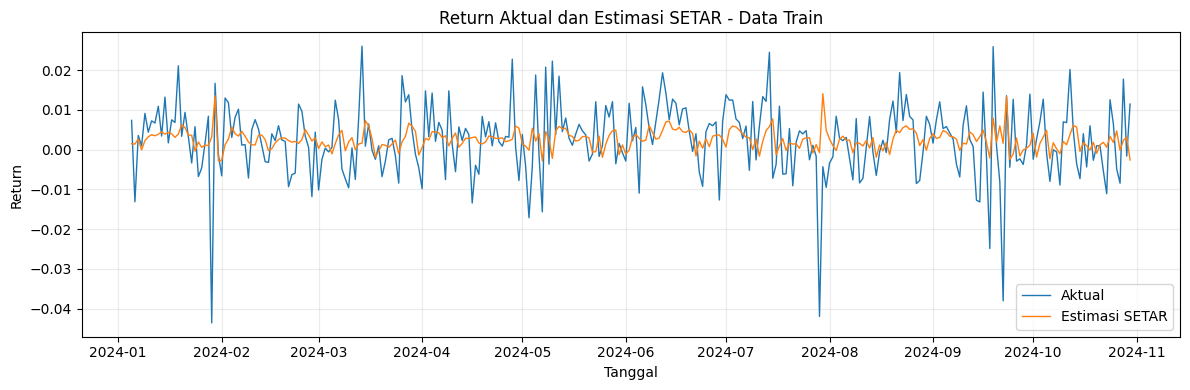

In [56]:
import matplotlib.pyplot as plt

dates_train_target = pd.to_datetime(target_dates_train)

plt.figure(figsize=(12, 4))
plt.plot(dates_train_target, b_train, label="Aktual", linewidth=1.0)
plt.plot(dates_train_target, pred_train_qr, label="Estimasi SETAR", linewidth=1.0)
plt.title("Return Aktual dan Estimasi SETAR - Data Train")
plt.xlabel("Tanggal")
plt.ylabel("Return")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Overlay kontinu data train dan test

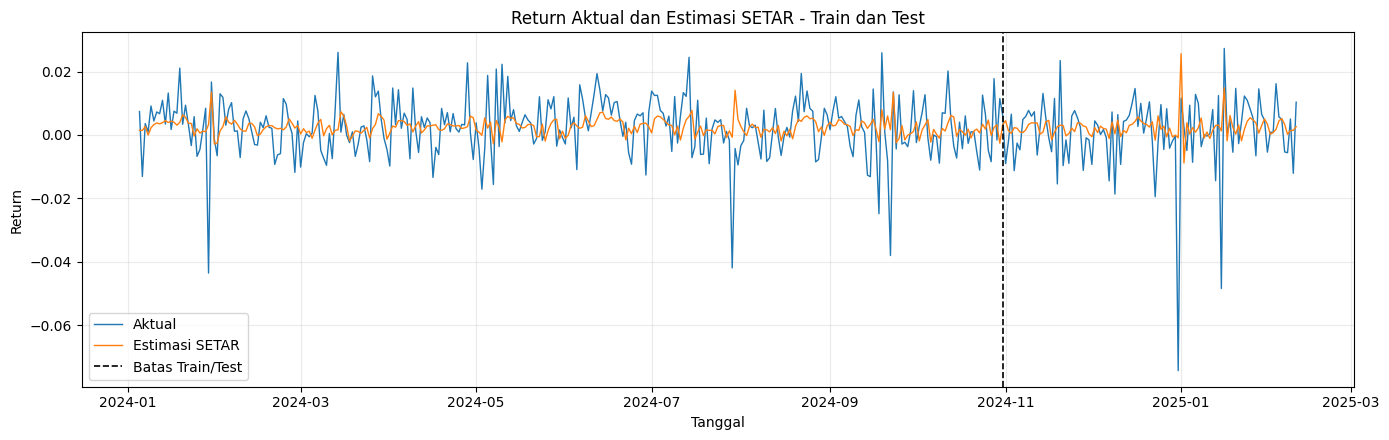

In [57]:
dates_continuous = np.concatenate([
    dates_train_target.to_numpy(),
    dates_test
])
actual_continuous = np.concatenate([b_train, b_test])
predicted_continuous = np.concatenate([pred_train_qr, pred_test_qr])

plt.figure(figsize=(14, 4.5))
plt.plot(dates_continuous, actual_continuous, label="Aktual", linewidth=1.0)
plt.plot(dates_continuous, predicted_continuous, label="Estimasi SETAR", linewidth=1.0)
plt.axvline(test_start, color="black", linestyle="--", linewidth=1.2, label="Batas Train/Test")
plt.title("Return Aktual dan Estimasi SETAR - Train dan Test")
plt.xlabel("Tanggal")
plt.ylabel("Return")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()